# GujEstateAI — Phase 2: Data Cleaning
**Input :** `data/raw/ProjectInfo_Gujarat.csv`  
**Output:** `data/processed/cleaned.csv`  
**Goal  :** Remove bad rows, fix nulls, remove outliers, save clean data  

Run cells one by one, top to bottom.
---

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


## Cell 2 — Load Raw Data

In [2]:
df = pd.read_csv("../data/raw/ProjectInfo_Gujarat.csv")

print(f"Raw data loaded")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

Raw data loaded
  Rows    : 14,507
  Columns : 44


## Cell 3 — Step 1: Drop Useless Columns
These columns have too many nulls (>30%) or are not useful for ML.  
We drop them to keep the dataset clean and simple.

In [3]:
# Columns to remove
cols_to_drop = [
    "pinCode",           # 47% nulls — not useful
    "tPNo",              # 51% nulls — not useful
    "architect_name",    # 32% nulls — not an ML feature
    "eng_name",          # 34% nulls — not an ML feature
    "projectAddress2",   # 8% nulls, duplicate of address
    "totalAreaOfLand",   # 40% nulls
    "AvgAreaOfLand",     # 40% nulls
]

df.drop(columns=cols_to_drop, inplace=True)

print("Columns dropped:", cols_to_drop)
print(f"\nDataset shape after dropping : {df.shape}")

Columns dropped: ['pinCode', 'tPNo', 'architect_name', 'eng_name', 'projectAddress2', 'totalAreaOfLand', 'AvgAreaOfLand']

Dataset shape after dropping : (14507, 37)


## Cell 4 — Step 2: Drop Rows With Missing Key Values
Some columns are essential — if a row is missing these, we can not use it.

In [4]:
rows_before = len(df)

# These columns are essential — drop rows where any of them is null
essential_cols = [
    "distName",           # district name — needed for all models
    "startProjectYear",   # needed to calculate duration
    "startProjectMonth",
    "EndProjectYear",
    "EndProjectMonth",
    "totalEstimatedCost", # target for Module 2
    "projectType",        # key feature for all models
]

df.dropna(subset=essential_cols, inplace=True)

rows_after = len(df)

print(f"  Rows before : {rows_before:,}")
print(f"  Rows after  : {rows_after:,}")
print(f"  Rows removed: {rows_before - rows_after:,}")

  Rows before : 14,507
  Rows after  : 13,630
  Rows removed: 877


## Cell 5 — Step 3: Calculate Duration
We create a new column `duration_months` — this is the **target variable for Module 1** (Duration Prediction).

Formula: `(EndYear - StartYear) * 12 + (EndMonth - StartMonth)`

In [5]:
df["duration_months"] = (
    (df["EndProjectYear"]  - df["startProjectYear"])  * 12 +
    (df["EndProjectMonth"] - df["startProjectMonth"])
)

print("duration_months column created")
print(f"\nSample values:")
print(df["duration_months"].head(10).values)
print(f"\nMin : {df['duration_months'].min()}")
print(f"Max : {df['duration_months'].max()}")
print(f"Mean: {df['duration_months'].mean():.1f} months")

duration_months column created

Sample values:
[ 66.  65.  51.  78.  50. 120.  78.  59.  69.  66.]

Min : 3.0
Max : 252.0
Mean: 53.5 months


## Cell 6 — Step 4: Remove Bad Duration Values
Some rows have negative or unrealistically long durations — these are data entry errors.  
We keep only projects with duration between **3 and 240 months** (3 months to 20 years).

In [6]:
rows_before = len(df)

df = df[
    (df["duration_months"] >= 3) &
    (df["duration_months"] <= 240)
].copy()

rows_after = len(df)

print(f"  Rows before : {rows_before:,}")
print(f"  Rows after  : {rows_after:,}")
print(f"  Rows removed: {rows_before - rows_after:,}")
print(f"\nDuration range now: {df['duration_months'].min()} to {df['duration_months'].max()} months")

  Rows before : 13,630
  Rows after  : 13,629
  Rows removed: 1

Duration range now: 3.0 to 213.0 months


## Cell 7 — Step 5: Remove Cost Outliers
A few projects have extremely high costs that are likely data errors.  
We remove the top 0.5% most expensive projects.

In [7]:
rows_before = len(df)

# Calculate the 99.5th percentile threshold
cost_threshold = df["totalEstimatedCost"].quantile(0.995)
print(f"  Cost threshold (99.5th pct) : Rs {cost_threshold:,.0f}")

# Remove rows above threshold
df = df[df["totalEstimatedCost"] <= cost_threshold].copy()

rows_after = len(df)

print(f"\n  Rows before : {rows_before:,}")
print(f"  Rows after  : {rows_after:,}")
print(f"  Rows removed: {rows_before - rows_after:,}")

# Show cost range now
cost_cr = df["totalEstimatedCost"] / 1e7
print(f"\n  Cost range now:")
print(f"    Min    : Rs {cost_cr.min():.2f} Cr")
print(f"    Median : Rs {cost_cr.median():.2f} Cr")
print(f"    Max    : Rs {cost_cr.max():.2f} Cr")

  Cost threshold (99.5th pct) : Rs 3,421,117,860

  Rows before : 13,629
  Rows after  : 13,560
  Rows removed: 69

  Cost range now:
    Min    : Rs 0.03 Cr
    Median : Rs 16.15 Cr
    Max    : Rs 339.02 Cr


## Cell 8 — Step 6: Remove Cost Per Sq.Ft Outliers
From EDA we saw some projects have extreme cost/sqft values.  
We remove the top 1% to keep the data sensible.

In [8]:
rows_before = len(df)

# Only apply filter where avgCostPerSqFt exists
sqft_threshold = df["avgCostPerSqFt"].quantile(0.99)
print(f"  sqft threshold (99th pct) : Rs {sqft_threshold:,.0f}")

# Remove rows where it exists AND is above threshold
mask = df["avgCostPerSqFt"].notna() & (df["avgCostPerSqFt"] > sqft_threshold)
df   = df[~mask].copy()

rows_after = len(df)

print(f"\n  Rows before : {rows_before:,}")
print(f"  Rows after  : {rows_after:,}")
print(f"  Rows removed: {rows_before - rows_after:,}")

  sqft threshold (99th pct) : Rs 105,362

  Rows before : 13,560
  Rows after  : 13,425
  Rows removed: 135


## Cell 9 — Step 7: Fix Remaining Nulls
Some columns still have a small number of nulls.  
We fill them with the **median** of their group (by project type) — this is better than filling with the overall median.

In [9]:
# Fill noOfInventory nulls with median per projectType
df["noOfInventory"] = df.groupby("projectType")["noOfInventory"]                         .transform(lambda x: x.fillna(x.median()))

# Fill avgCostPerSqFt nulls with median per projectType
df["avgCostPerSqFt"] = df.groupby("projectType")["avgCostPerSqFt"]                          .transform(lambda x: x.fillna(x.median()))

# Fill totalUnits and bookedUnits with median (very few nulls)
df["totalUnits"]  = df["totalUnits"].fillna(df["totalUnits"].median())
df["bookedUnits"] = df["bookedUnits"].fillna(df["bookedUnits"].median())

# Fill other small null columns with median
small_null_cols = [
    "avgUnits", "totalSellingAmount", "bookedSellingAmount",
    "totalReceivedAmount", "bookedReceivedAmount",
    "totalCarpetArea_form3A", "totalBuiltupArea_form3A",
    "totalSquareFootBuild", "AvgSquareFootBuild", "avgCostPerUnit"
]
for col in small_null_cols:
    df[col] = df[col].fillna(df[col].median())

print("Nulls filled successfully")

# Show remaining nulls
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
if len(remaining) == 0:
    print("\nNo nulls remaining in key columns!")
else:
    print("\nRemaining nulls (non-essential columns):")
    print(remaining.to_string())

Nulls filled successfully

Remaining nulls (non-essential columns):
promoterName              1
projectAddress            1
location_coordinates    399


## Cell 10 — Step 8: Create Booking Rate Column
We create `booking_rate` = booked units / total units.  
This is a key feature for the Investment Scoring module later.

In [10]:
df["booking_rate"] = df["bookedUnits"] / df["totalUnits"]

# Some edge cases — clip between 0 and 1
df["booking_rate"] = df["booking_rate"].clip(0, 1)

print("booking_rate column created")
print(f"\n  Min    : {df['booking_rate'].min():.2f}")
print(f"  Median : {df['booking_rate'].median():.2f}  ({df['booking_rate'].median()*100:.1f}%)")
print(f"  Max    : {df['booking_rate'].max():.2f}")
print(f"  Nulls  : {df['booking_rate'].isnull().sum()}")

booking_rate column created

  Min    : 0.00
  Median : 0.58  (58.2%)
  Max    : 1.00
  Nulls  : 0


## Cell 11 — Step 9: Reset Index
After all the row removals, the index numbers have gaps.  
We reset it to be clean and sequential.

In [11]:
df.reset_index(drop=True, inplace=True)

print("Index reset successfully")
print(f"\nFinal cleaned dataset:")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

Index reset successfully

Final cleaned dataset:
  Rows    : 13,425
  Columns : 39


## Cell 12 — Cleaning Summary: Before vs After
Let us see how much data we removed in total.

In [12]:
original = 14507   # original row count from EDA

print("=" * 45)
print("  CLEANING SUMMARY")
print("=" * 45)
print(f"  Original rows  : {original:,}")
print(f"  Cleaned rows   : {len(df):,}")
print(f"  Rows removed   : {original - len(df):,}  ({(original - len(df))/original*100:.1f}%)")
print(f"  Rows kept      : {len(df)/original*100:.1f}%")
print()
print(f"  Original columns : 44")
print(f"  Cleaned columns  : {df.shape[1]}")
print(f"  Columns removed  : {44 - df.shape[1]}")
print()
print("  Key column null check (should all be 0):")
key_cols = ["projectType", "distName", "totalEstimatedCost",
            "duration_months", "totalUnits", "bookedUnits", "booking_rate"]
for col in key_cols:
    nulls = df[col].isnull().sum()
    status = "OK" if nulls == 0 else f"STILL HAS {nulls} nulls!"
    print(f"    {col:<30}  {nulls}  nulls  ->  {status}")
print("=" * 45)

  CLEANING SUMMARY
  Original rows  : 14,507
  Cleaned rows   : 13,425
  Rows removed   : 1,082  (7.5%)
  Rows kept      : 92.5%

  Original columns : 44
  Cleaned columns  : 39
  Columns removed  : 5

  Key column null check (should all be 0):
    projectType                     0  nulls  ->  OK
    distName                        0  nulls  ->  OK
    totalEstimatedCost              0  nulls  ->  OK
    duration_months                 0  nulls  ->  OK
    totalUnits                      0  nulls  ->  OK
    bookedUnits                     0  nulls  ->  OK
    booking_rate                    0  nulls  ->  OK


## Cell 13 — Quick Visual Check: Clean vs Raw
Plot cost and duration distributions to confirm data looks normal after cleaning.

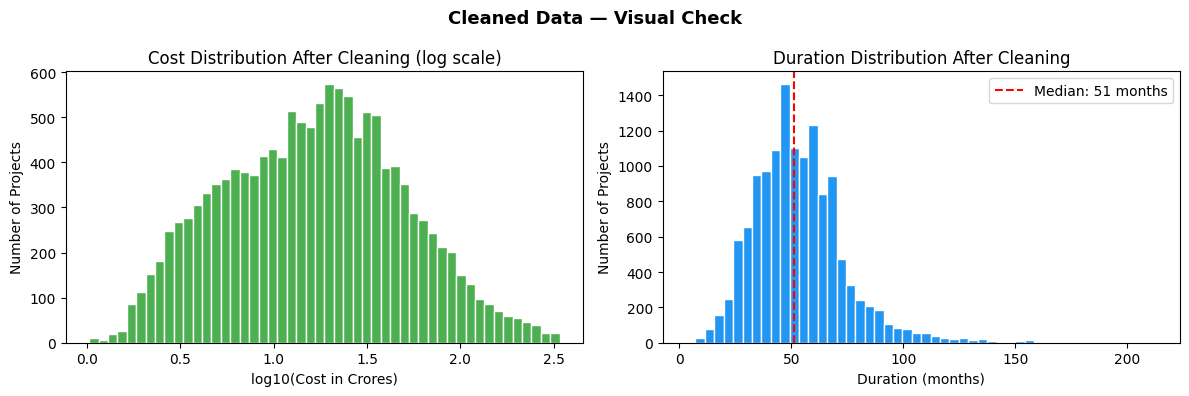

Chart saved to reports/10_cleaned_distributions.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cost distribution
cost_cr = df["totalEstimatedCost"] / 1e7
axes[0].hist(np.log10(cost_cr + 1), bins=50, color="#4CAF50", edgecolor="white")
axes[0].set_title("Cost Distribution After Cleaning (log scale)")
axes[0].set_xlabel("log10(Cost in Crores)")
axes[0].set_ylabel("Number of Projects")

# Duration distribution
axes[1].hist(df["duration_months"], bins=50, color="#2196F3", edgecolor="white")
axes[1].axvline(df["duration_months"].median(), color="red", linestyle="--",
                label=f"Median: {df['duration_months'].median():.0f} months")
axes[1].set_title("Duration Distribution After Cleaning")
axes[1].set_xlabel("Duration (months)")
axes[1].set_ylabel("Number of Projects")
axes[1].legend()

plt.suptitle("Cleaned Data — Visual Check", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/10_cleaned_distributions.png", dpi=150)
plt.show()
print("Chart saved to reports/10_cleaned_distributions.png")

## Cell 14 — Save Cleaned Data
Save the cleaned dataset to `data/processed/cleaned.csv`.  
This file will be used in Phase 3 (Feature Engineering).

In [14]:
import os

# Make sure the folder exists
os.makedirs("../data/processed", exist_ok=True)

# Save
df.to_csv("../data/processed/cleaned.csv", index=False)

print("Cleaned data saved!")
print("  Location : data/processed/cleaned.csv")
print(f"  Shape    : {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Next step: Open 03_feature_engineering.ipynb for Phase 3")

Cleaned data saved!
  Location : data/processed/cleaned.csv
  Shape    : 13,425 rows x 39 columns

Next step: Open 03_feature_engineering.ipynb for Phase 3
